# Personal Information
Name: **Evelina Lune**

StudentID: **16190890**

Email: [**evelina.lune@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **23.03.2025**

Link to GitHub: **https://github.com/eVV44/MSc-DS-thesis.git**

# Data Context
For the experiments I will use the MS MARCO Passage Ranking dataset, which is a standard benchmark for neural reranking.
The dataset contains queries, passages, and manually annotated relevance labels called qrels, which serve as the ground truth.

In a reranking setup, an initial retrieval system (like BM25) retrieves candidate passages, and a neural reranker such as DuoBERT reorders these candidates based on predicted relevance.

Files used:
- queries.dev.tsv: query text
- qrels.dev.tsv: ground truth relevance labels
- top1000.dev: candidate passages per query

# Data Description
The exploratory analysis focuses on understanding the structure and distribution of the MS MARCO development data used in the reranking experiments. 

In particular, the analysis examines:
- the number of queries and relevance annotations,
- the distribution of relevant passages per query,
- the level of class imbalance in the candidate ranking set,
- the length distribution of queries and passages,
- the proportion of queries that do not contain a relevant passage in their retrieved candidate set,
- the main characteristics of the query vocabulary,
- the relationship between query length and the number of relevant passages.

Understanding these properties is important because they influence both the training and evaluation of neural rerankers and the interpretation of explanation methods. For example, the strong class imbalance and the sparse number of relevant passages per query make the ranking task challenging and affect how explanation faithfulness should be evaluated.

The following sections present several analyses that characterize these aspects of the dataset.

- Analysis 1: Dataset structure
- Analysis 2: Relevant passages per query
- Analysis 3: Class imbalance
- Analysis 4: Query and passage length
- Analysis 5: Queries with zero relevant candidates
- Analysis 6: Relevant vs non-relevant passages
- Analysis 7: Query Vocabulary Characteristics
- Analysis 8: Query length vs relevant passages

In [78]:
# -- IMPORTS --
import os
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import nltk
from nltk.corpus import stopwords

sns.set(style="whitegrid")

### Data Loading

In [79]:
# Load queries
queries_path = "../data/msmarco_passage_dev/raw/queries.dev.tsv"
queries = pd.read_csv(queries_path, sep="\t", header=None, names=["query_id", "query"])
queries.head()

# Load qrels
qrels_path = "../data/msmarco_passage_dev/raw/qrels.dev.tsv"
qrels = pd.read_csv(qrels_path, sep="\t", header=None, names=["query_id", "unused", "pid", "relevance"])
qrels = qrels.drop(columns=["unused"])
qrels.head()

# Load candidate passages
top1000_path = "../data/msmarco_passage_dev/raw/top1000.dev"
top1000 = pd.read_csv(top1000_path, sep="\t", header=None, names=["query_id", "pid", "query", "passage", "rank"])

### Analysis 1: Corpus Structure
This section explores the structure of the MS MARCO Passage Ranking development dataset. The focus is on analyzing:
- number of queries
- number of relevance judgements (qrels)
- unique queries and passages
- the structure of the ground truth labels

In [80]:
# Number of rows
num_queries = len(queries)
num_qrels = len(qrels)

# Unique identifiers
unique_query_ids = queries["query_id"].nunique()
unique_qrels_qids = qrels["query_id"].nunique()
unique_passages = qrels["pid"].nunique()

print("Number of queries:", num_queries)
print("Unique query IDs (queries file):", unique_query_ids)
print()
print("Number of qrels (relevance judgments):", num_qrels)
print("Unique query IDs (qrels file):", unique_qrels_qids)
print("Unique passage IDs (in qrels):", unique_passages)

Number of queries: 101093
Unique query IDs (queries file): 101093

Number of qrels (relevance judgments): 59273
Unique query IDs (qrels file): 55578
Unique passage IDs (in qrels): 59096


**Key takeaway**: Only about 55k of the 101k queries have relevance labels, so evaluation focuses on those queries.

### Interpretation
- The MS MARCO Passage Ranking development set contains 101,093 queries, as provided in queries.dev.tsv. These represent all queries that are available for evaluation in the dev setting.

- The relevance file qrels.dev.tsv contains 59,273 relevance judgements. Each row in this file corresponds to one manually annotated (query, passage) pair indicating that the passage is relevant to the query.

- However, these 59,273 relevance judgements correspond to only 55,578 unique query IDs. This means that 55,578 out of the 101,093 development queries have at least one labeled relevant passage. In other words, not every development query has associated gorund-truth relevance labels.

- The relevance judgemnents refer to 59,096 unique passage IDs, indicating that most passages are judged relevant to a single query, although some passsages may be relevant to multiple queries.

Overall, this shows that evaluation in the development set is restricted to the subset of queries that have relevance annotations. Queries without labeled relevant passages cannot contribute to ranking evaluation. 

### Analysis 2: Distribution of Relevant Passages per Query
In this section, we analyze how many relevant passages are associated with each query. Understanding this is important because...
- It reflects the difficulty of the ranking task
- It determines how many positive examples exist per query
- It affects the construction of pairwise comparisons (relevant vs. non-relevant)
- It influences evaluation metrics and explanation analysis

We therefore compute the number of relevant passages per query and examine its distribution.

In [81]:
# Count number of relevant passages per query
relevant = qrels.groupby("query_id")["pid"].nunique()

print(relevant.describe())

count    55578.000000
mean         1.066483
std          0.295206
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: pid, dtype: float64


**Key takeaway**: Most queries have only one relevant passage, which makes the ranking task sparse and difficult.

### Interpretation
The distribution of relevant passages per query reveals that the relevance signal in the development set is highly sparse. Among the 55,578 queries that have at least one relevance judgement:
- The avg number of relevant passages per query is 1.07
- The median is 1, and 75% of the queries have exactly one relevant passage
- The maximum number of relevant passages for any query is 6

This indicates that, for most queries, there is only a single relevant passage in the ground truth. The ranking task is therefore highly sparse in positive examples. For a typical query, the model must distinguish one relevant passage from a large set of non-relevant candidates, making the problem inherently imbalanced.

### Analysis 3: Class Imbalance
This analysis examines the distribution of relevant and non-relevant passages within the reranking candidate set. By merging candidate passages with the relevance judgments, we quantify the degree of class imbalance and assess its implications for model evaluation and baseline performance.

In [82]:
print("Number of candidate rows:", len(top1000))
print("Unique queries in top1000:", top1000["query_id"].nunique())

# How many candidates per query?
candidates_per_query = top1000.groupby("query_id")["pid"].count()
print(candidates_per_query.describe())

# Keep only relevant judgements for queries
qrels_subset = qrels[qrels["query_id"].isin(top1000["query_id"])]

# Merge
candidates = top1000.merge(qrels_subset[["query_id", "pid", "relevance"]], on=["query_id", "pid"], how="left")
candidates["relevance"] = candidates["relevance"].fillna(0)

# Class distribution 
class_counts = candidates["relevance"].value_counts()
print(class_counts) 

relevant_percentage = class_counts[1] / len(candidates) * 100
print("Percentage relevant:", round(relevant_percentage, 4), "%")

relevant_per_query = candidates.groupby("query_id")["relevance"].sum()
print(relevant_per_query.describe())

# Baseline accuracy
baseline_accuracy = (candidates["relevance"] == 0).mean()
print("Majority class baseline accuracy:", round(baseline_accuracy * 100, 2), "%")

Number of candidate rows: 6668967
Unique queries in top1000: 6980
count    6980.000000
mean      955.439398
std       191.734921
min         1.000000
25%      1000.000000
50%      1000.000000
75%      1000.000000
max      1000.000000
Name: pid, dtype: float64
relevance
0.0    6662962
1.0       6005
Name: count, dtype: int64
Percentage relevant: 0.09 %
count    6980.000000
mean        0.860315
std         0.452470
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: relevance, dtype: float64
Majority class baseline accuracy: 99.91 %


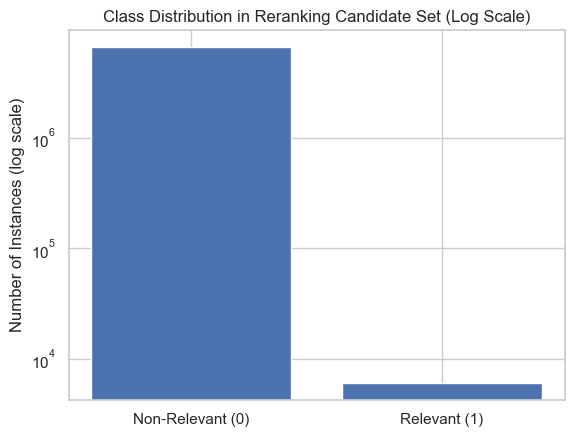

In [83]:
# Count classes
class_counts = candidates["relevance"].value_counts().sort_index()

plt.figure()
plt.bar(["Non-Relevant (0)", "Relevant (1)"], class_counts.values)
plt.yscale("log")
plt.title("Class Distribution in Reranking Candidate Set (Log Scale)")
plt.ylabel("Number of Instances (log scale)")
plt.show()

**Key takeaway**: Only 0.09% of candidate passages are relevant, showing extreme class imbalance.

### Interpretation
- The top1000.dev file contains 6,668,967 query–passage candidate pairs for 6,980 unique queries. Although the file is intended to provide 1000 candidates per query, the average number of candidates per query is 955, with a minimum of 1 and a median of 1000. This means that most queries have 1000 candidates, but some have fewer

- After merging the candidate set with the relevance judgments, only 6,005 out of 6,668,967 candidate passages are labeled as relevant. This corresponds to 0.09% relevant passages and 99.91% non-relevant passages

- At the query level, the average number of relevant passages within the 1000 candidates is 0.86, with a median of 1 and a maximum of 4. Some queries have zero relevant passages among their candidates

- This shows that the reranking task is extremely imbalanced. A majority-class baseline that predicts all passages as non-relevant achieves 99.91% accuracy, meaning that accuracy is not an appropriate evaluation metric. Instead, ranking-based metrics must be used. This strong imbalance also increases the difficulty of identifying which features truly influence ranking decisions

### Analysis 4: Text Length Distribution
In this section, we analyze the length of queries and passages in the reranking candidate set. Since DuoBERT is a cross-encoder model with a maximum input length of 512 tokens, understanding the distribution of text lengths is important. If passages are frequently longer than the maximum input length, truncation may occur, which can influence both ranking performance and token-level explanations produced by Integrated Gradients. To estimate length statistics efficiently, we compute them on a representative subset of the candidate set.

In [84]:
top1000_sample = pd.read_csv(top1000_path, sep="\t", header=None, names=["query_id", "pid", "query", "passage"], usecols=[0,1,2,3], nrows=50000)
top1000_sample["query_length"] = top1000_sample["query"].str.split().str.len()
top1000_sample["passage_length"] = top1000_sample["passage"].str.split().str.len()

top1000_sample[["query_length", "passage_length"]].describe()

,query_length,passage_length
count,50000.000000,50000.00000
mean,5.922160,56.92282
std,2.511045,23.55703
min,2.000000,6.00000
25%,4.000000,42.00000
50%,6.000000,51.00000
75%,7.000000,67.00000
max,30.000000,214.00000


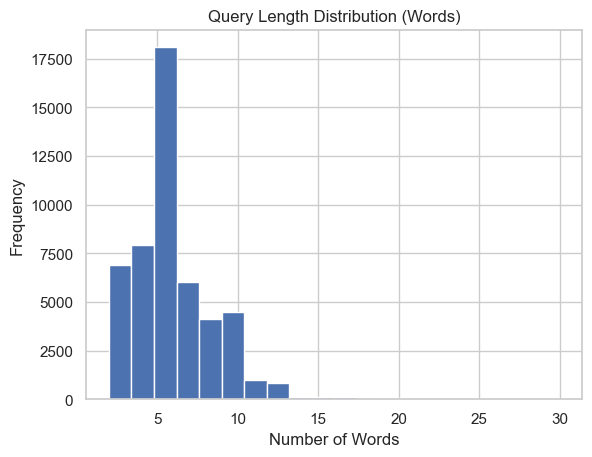

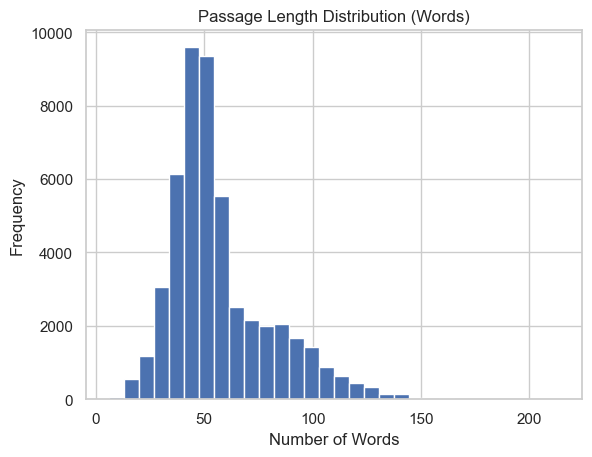

In [85]:
# Query length histogram
plt.figure()
plt.hist(top1000_sample["query_length"], bins=20)
plt.title("Query Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Passage length histogram
plt.figure()
plt.hist(top1000_sample["passage_length"], bins=30)
plt.title("Passage Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

**Key takeaway**: Queries are short (±6 words) while passages are longer (±50 words), which is typical for web search tasks.

### Intepretation

Queries:
- The average query length is 5.9 words, with a median of 6 words
- 75% of queries contain 7 words or fewer, indicating that queries are generally short
- The longest query in the sample contains 30 words, but such cases are rare
- The query length distribution is right-skewed but tightly concentrated between 3 and 8 words. Extremely long queries are rare

Passages:
- The average passage length is 56.9 words, with a median of 51 words
- 75% of passages contain 67 words or fewer, showing that most passages are moderately short
- The longest passage in the sample contains 214 words
- The passage length distribution is moderately right-skewed, with most passages between 40 and 70 words. A small number of longer passages form a light tail, but extreme outliers are limited

Combination and BERT:
- When combining query and passage text, the total input length is typically well below the 512-token limit of BERT-based cross-encoders such as DuoBERT
- This suggests that input truncation is unlikely to be a major issue in the reranking setup

As a result, most tokens in the passage are available to the model, which is important for interpreting token-level attributions produced by Integrated Gradients.

### Analysis 5: Queries with Zero Relevant Candidates
This analysis examines how many queries in the reranking candidate set have no labeled relevant passages. Identifying such queries is important because they cannot contribute to learning or evaluation based on relevance, and may affect ranking metrics and explanation analysis.

In [86]:
# Queries with zero relevant passages
zero_relevant_queries = (relevant_per_query == 0).sum()

print("Number of queries with zero relevant passages:", zero_relevant_queries)
print("Total queries:", len(relevant_per_query))

print("Percentage:", round(zero_relevant_queries / len(relevant_per_query) * 100, 2), "%")

Number of queries with zero relevant passages: 1242
Total queries: 6980
Percentage: 17.79 %


**Key takeaway**: About 18% of queries have no relevant passage in the top-1000 candidate set, meaning the retrieval stage sometimes fails before reranking even begins.

### Interpretation
Out of the 6,980 queries in the reranking candidate set, 1,242 queries (17.79%) have no relevant passages among their top 1000 candidates.

This means that for nearly one-fifth of the queries, the candidate retrieval stage fails to retrieve any ground-truth relevant passage. For these queries:

- Ranking metrics such as NDCG will necessarily be zero
- Pairwise comparisons between relevant and non-relevant passages cannot be constructed
- Faithfulness analysis based on positive instances is not applicable

This has methodological implications for the experimental setup. Queries without any relevant candidates may need to be excluded from certain analyses, particularly those involving pairwise explanation evaluation.

### Analysis 6: Relevant vs Non-Relevant Passage Characteristics
This analysis compares passage length between relevant and non-relevant passages in the reranking candidate set. To account for class imbalance, all relevant passages were matched with an equal-sized sample of non-relevant passages, allowing for a fair comparison of their structural characteristics.

In [87]:
relevant_pairs = candidates[candidates["relevance"] == 1][["query_id", "pid"]]
print("Relevant pairs:", len(relevant_pairs))

nonrelevant_pairs = candidates[candidates["relevance"] == 0][["query_id", "pid"]].sample(n=len(relevant_pairs), random_state=42)

balanced_pairs = pd.concat([relevant_pairs.assign(relevance=1), nonrelevant_pairs.assign(relevance=0)])
print(balanced_pairs["relevance"].value_counts())

# Make a fast lookup key
balanced_pairs["key"] = balanced_pairs["query_id"].astype(str) + "_" + balanced_pairs["pid"].astype(str)
keys = set(balanced_pairs["key"])

chunks = []
for chunk in pd.read_csv(top1000_path, sep="\t", header=None, names=["query_id", "pid", "query", "passage"], chunksize=200000):
    chunk["key"] = chunk["query_id"].astype(str) + "_" + chunk["pid"].astype(str)
    hit = chunk[chunk["key"].isin(keys)]
    
    if not hit.empty:
        chunks.append(hit)

balanced_text = pd.concat(chunks, ignore_index=True)

# Add relevance labels back
balanced_text["key"] = balanced_text["query_id"].astype(str) + "_" + balanced_text["pid"].astype(str)
balanced_text = balanced_text.merge(balanced_pairs[["key", "relevance"]],on="key", how="left")

balanced_text["relevance"].value_counts()

Relevant pairs: 6005
relevance
1    6005
0    6005
Name: count, dtype: int64


relevance
1    6005
0    6005
Name: count, dtype: int64

In [88]:
balanced_text["passage_length_words"] = balanced_text["passage"].str.split().str.len()
balanced_text.groupby("relevance")["passage_length_words"].describe()

,count,mean,std,min,25%,50%,75%,max
relevance,,,,,,,,
0,6005.0,57.003997,23.470153,10.0,42.0,51.0,68.0,174.0
1,6005.0,54.552873,21.610763,10.0,41.0,50.0,63.0,191.0


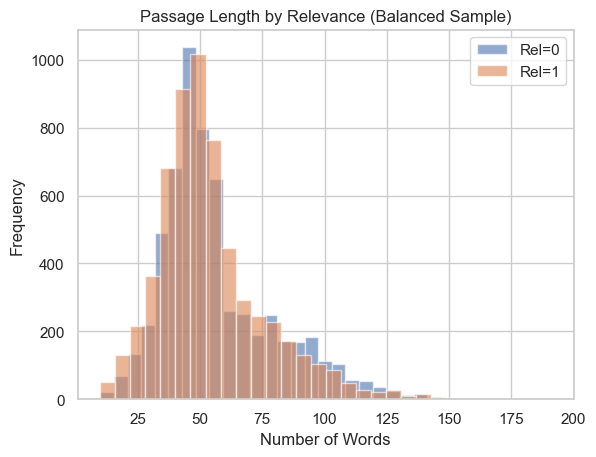

In [89]:
plt.figure()
for label, group in balanced_text.groupby("relevance"):
    plt.hist(group["passage_length_words"], bins=30, alpha=0.6, label=f"Rel={int(label)}")
plt.legend()
plt.title("Passage Length by Relevance (Balanced Sample)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

**Key takeaway**: Passage length distributions are similar, meaning relevance cannot be determined from simple surface features.

# check tf idf

### Interpretation
After balancing the dataset to include all 6,005 relevant passages and an equal number of non-relevant passages, the length distributions were compared:

- Non-relevant passages have a mean length of 57.0 words.
- Relevant passages have a mean length of 54.6 words.
- The medians are nearly identical (51 vs 50 words).
- The spread and interquartile ranges are very similar.
- Both distributions show a right-skewed tail with some longer passages.
- The small difference in average length (≈2-3 words) is negligible relative to the overall variability.

**Key Insight**: passage length does not meaningfully differentiate relevant from non-relevant passages in the MS MARCO dev candidate set. Therefore, simple structural features such as length are unlikely to explain model relevance decisions. Neural rerankers must rely primarily on semantic matching rather than superficial length cues

### Analysis 7: Query Vocabulary Characteristics
This analysis examines the vocabulary used in the query set to better understand the language characteristics of the dataset. In particular, it analyzes the frequency of query terms and the overall vocabulary size after removing common stopwords.

In [90]:
# nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
all_words = " ".join(queries["query"]).lower().split()

# remove stopwords
filtered_words = [w for w in all_words if w not in stop_words]
vocab = Counter(filtered_words)

print("Vocabulary size:", len(vocab))

print("\nTop 15 most common query terms:")
for word, count in vocab.most_common(15):
    print(word, ":", count)

Vocabulary size: 55218

Top 15 most common query terms:
definition : 3708
long : 3087
many : 2885
much : 2811
cost : 2446
mean : 2078
number : 2006
meaning : 1923
average : 1864
get : 1431
causes : 1418
county : 1368
name : 1235
take : 1190
weather : 1178


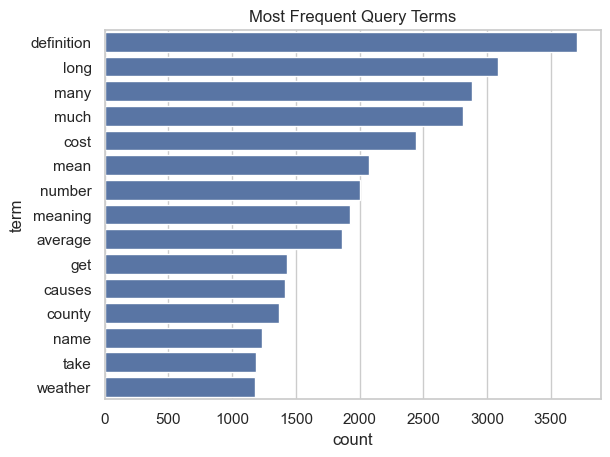

In [91]:
top_terms = pd.DataFrame(vocab.most_common(15), columns=["term", "count"])

sns.barplot(data=top_terms, x="count", y="term")
plt.title("Most Frequent Query Terms")
plt.show()

**Key takeaway**: The query vocabulary contains ~55k unique terms, showing the dataset covers diverse information needs.

# what docs what queries is ms marco

### Interpretation
- After removing common stopwords, the query vocabulary contains 55218 unique terms, indicating a large variety of search topics in the dataset.

- The most frequent query terms include words such as *definition, long, many*, and *cost*, which suggests that many queries correspond to informational questions or factual lookups.
- This indicates that the dataset reflects natural user search behaviour, where queries often ask for definitions, quantities, or explanations.
- As a result, neural rerankers must capture semantic relationships between queries and passages, rather than relying solely on simple keyword matching.

### Analysis 8: Query length vs Relevance
Do longer queries retrieve more relevant passages?

In [92]:
query_lengths = queries.copy()
query_lengths["query_length"] = query_lengths["query"].str.split().apply(len)

relevant_counts = qrels.groupby("query_id")["pid"].count().reset_index()
relevant_counts.columns = ["query_id", "num_relevant"]

query_analysis = query_lengths.merge(relevant_counts, on="query_id", how="left")
query_analysis["num_relevant"] = query_analysis["num_relevant"].fillna(0)

query_analysis[["query_length","num_relevant"]].corr()

,query_length,num_relevant
query_length,1.000000,-0.183285
num_relevant,-0.183285,1.000000


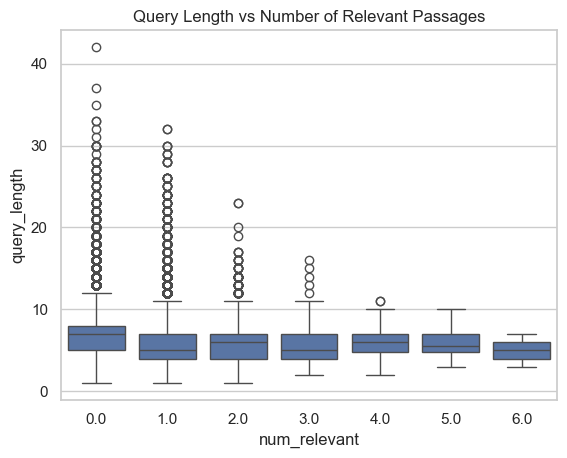

In [93]:
sns.boxplot(x="num_relevant", y="query_length", data=query_analysis)
plt.title("Query Length vs Number of Relevant Passages")
plt.show()

**Key takeaway**: Query length does not strongly correlate with the number of relevant passages (correlation ≈ −0.18). Query difficulty is not simply determined by query length.

### Interpretation
This analysis examines whether query length is related to the number of relevant passages associated with a query.

- The boxplot shows that most queries have a length between 4 and 7 words, regardless of how many relevant passages they have.
- The correlation between query length and the number of relevant passages is -0.18, indicating a very weak negative relationship. This suggests that query length does not strongly influence how many relevant passages exist for a query.

Therefore, the difficulty of the ranking task is likely driven more by **semantic relevance** between the query and passages than by simple surface characteristics such as query length.

# to do:
- what are difficult/simple queries based on duobert
- how can we find easy to determine if its easy or hard (rank and see if the doc appears on top or not. if on top --> easy for the ranker)
- examples where model performs bad / think about ways that are not gradient (feeling for the problem). why did that happen just by looking

- use 2 datasets later: if examples are too easy (another data for the model). a hard dataset. different qrels for different tasks later check. say 2nd dataset will be selected ater the findings of the first runs. reporting on different domains (medical, legal)